# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alsa-mirza/flyrank-ml-internship/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [9]:
!git clone https://github.com/alsa-mirza/flyrank-ml-internship.git

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.


In [10]:
import os

for root, dirs, files in os.walk("flyrank-ml-internship"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

flyrank-ml-internship/data/raw/content_refresh_anonymized.csv
flyrank-ml-internship/outputs/refresh_queue_sample.csv


In [11]:
import pandas as pd

df = pd.read_csv("flyrank-ml-internship/data/raw/content_refresh_anonymized.csv")

print("Rows, Columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Rows, Columns: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

First 5 rows:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [12]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nSearch Volume Statistics:")
print(df["search_volume"].describe())

Rows: 30000
Columns: 44

Missing values:
provider_used        21438
word_count            7699
char_count            7699
word_count_tier       7699
char_count_tier       7699
model_used            5733
trend_pct             3388
competition_level     2610
search_volume         2468
cpc                   2468
dtype: int64

Search Volume Statistics:
count    27532.000000
mean       158.882391
std       1518.270825
min          0.000000
25%          0.000000
50%         10.000000
75%         20.000000
max      74000.000000
Name: search_volume, dtype: float64


In [13]:
for col in df.columns:
    if "ctr" in col.lower() or "position" in col.lower():
        print(col)

ctr
avg_position
position_tier


       avg_position           ctr
count   30000.00000  30000.000000
mean       16.34238      0.510733
std        15.21679      3.279162
min         0.00000      0.000000
25%         6.20000      0.000000
50%        10.80000      0.070000
75%        22.30000      0.290000
max       245.00000    100.000000


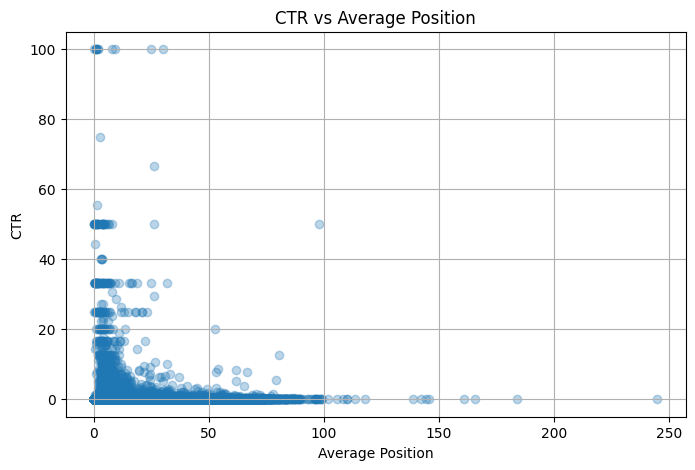

In [14]:
import matplotlib.pyplot as plt

data = df[["avg_position", "ctr"]].dropna()

print(data.describe())

plt.figure(figsize=(8,5))
plt.scatter(data["avg_position"], data["ctr"], alpha=0.3)
plt.xlabel("Average Position")
plt.ylabel("CTR")
plt.title("CTR vs Average Position")
plt.grid(True)
plt.show()

In [15]:

avg_ctr = (
    df.groupby("position_tier")["ctr"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_ctr)

position_tier
top_3       1.483611
page_1      0.652467
striking    0.323239
page_3_5    0.222484
deep        0.150212
Name: ctr, dtype: float64


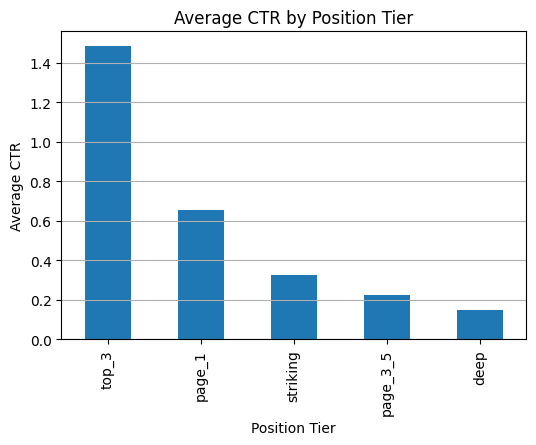

In [16]:
import matplotlib.pyplot as plt

avg_ctr.plot(kind="bar", figsize=(6,4))

plt.title("Average CTR by Position Tier")
plt.xlabel("Position Tier")
plt.ylabel("Average CTR")
plt.grid(axis="y")

plt.show()

I decided to choose the CTR improvement lane because the starter notebook showed that click-through rate changes depends highly on search position. This is a very important problem related to SEO because making CTR better can increase traffic without producing any new content. I want to have a clear understanding about which pages have low CTR for their position and identify opportunities to improve them. This project focuses on improving SEO decisions using data instead of assumptions.



Decision: The decision is to identify which pages should be optimized to improve the CTR (click-through rate).

Action: The action could be that an SEO specialist can improve page titles, meta descriptions, and search snippets for pages that have lower CTR than expected for their search position.

Cost of a Wrong Recommendation: If the recommendation is wrong, then in this case the time and effort may be spent in optimizing the wrong pages. This could reduce productivity and delay improvements on pages that have relatively better opportunities for increasing traffic.


Quick Look at the Data:

The starter dataset consisted of 30,000 rows and 44 columns. I analyzed the relationship between average search position and CTR. The dataset includes important features of SEO such as CTR, average position, search volume, and position tier. I also generated summary statistics and visualizations to better understand the data. These results suggest that CTR varies with search position, making this a useful problem for machine learning and SEO optimization.

This analysis helped me in identifying patterns in the available dataset, but it does not prove that one factor directly causes another. A machine learning model can help prioritize pages for optimization, but human review is still important before making business decisions using AI for better results.

Self Check:
- I selected a provisional lane.
- I clearly explained the decision, action, and cost of a wrong recommendation.
- I supported my choice using real numbers from the starter dataset.
- I used careful language and avoided making unsupported claims.